# COVID-19 SIR Model with Optimal Control

## Numerical Solution Using the Forward-Backward Sweep Method

This notebook implements the COVID-19 optimal-control model of
Ahmed, Khan, and Sarker (2023).

The numerical procedure is:

1. Initialize the control variables.
2. Solve the state system forward in time using Euler's method.
3. Solve the adjoint system backward in time using Euler's method.
4. Compute the new controls from the optimality characterization.
5. Update the controls using a convex combination of the new and previous
   control estimates.
6. Enforce the bounds 0 <= u1, u2 <= 1.
7. Check convergence.
8. Repeat until convergence.

The convex-combination update follows the numerical recommendation of
Lenhart and Workman (2007, p. 50).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# ============================================================
# MODEL PARAMETERS
# ============================================================

beta_d = 0.75          # Direct transmission rate
Delta = 0.03           # Recruitment rate
beta_e = 1.5e-10       # Indirect transmission rate
alpha = 0.5             # Treatment/cure rate
mu_c = 1.0e-6           # Natural death rate
b = 1.2e-5              # Saturation parameter
mu_v = 5.0e-5           # Disease-induced death rate
gamma = 3.0e-3          # Natural recovery rate
rho = 0.8                # Vaccination parameter


# ============================================================
# OBJECTIVE FUNCTION WEIGHTS
# ============================================================

b1 = 2.0
w1 = 1.0e8
w2 = 1.0e9


# ============================================================
# INITIAL CONDITIONS
# ============================================================

S0 = 174673.0
I0 = 132.0
R0 = 0.0


# ============================================================
# TIME DOMAIN
# ============================================================

t0 = 0.0
T = 50.0

N = 1001

t = np.linspace(t0,T,N)

h = t[1] - t[0]


# ============================================================
# ITERATION PARAMETERS
# ============================================================

tol = 1.0e-7
max_iter = 1000


# ============================================================
# CONVEX-COMBINATION PARAMETER
# ============================================================

theta = 0.5

print("Step size h =", h)
print("Convex-combination parameter theta =", theta)

Step size h = 0.05
Convex-combination parameter theta = 0.5


In [3]:
# ============================================================
# CONTROLLED STATE SYSTEM
# ============================================================

def state_rhs(S,I,R,u1,u2):
    """
    Controlled COVID-19 SIR model.

    Parameters
    ----------
    S : float
        Susceptible population.

    I : float
        Infected population.

    R : float
        Recovered population.

    u1 : float
        Face mask, hand sanitizer,
        and social distancing control.

    u2 : float
        Vaccination control.

    Returns
    -------
    dS, dI, dR
    """

    # Avoid division by zero
    denominator = max(S + I,1.0e-14)

    # Direct transmission
    direct = (beta_d*S*I)/denominator

    # Indirect transmission
    indirect = beta_e*S*I


    # Saturated treatment
    treatment = (alpha*I)/(1.0 + b * I)


    # --------------------------------------------------------
    # SUSCEPTIBLE EQUATION
    # --------------------------------------------------------

    dS = Delta - direct - indirect - mu_c*S + treatment - (u1+rho*u2)*S


    # --------------------------------------------------------
    # INFECTED EQUATION
    # --------------------------------------------------------

    dI = direct + indirect - treatment - (mu_c + mu_v + gamma)*I - u1*I


    # --------------------------------------------------------
    # RECOVERED EQUATION
    # --------------------------------------------------------

    dR = u1*(S+I) + rho*u2*S + gamma*I- mu_c*R


    return dS, dI, dR

In [4]:
# ============================================================
# ADJOINT SYSTEM
# ============================================================

def adjoint_rhs(S,I,R,u1,u2,lam1,lam2,lam3):
    """
    Adjoint equations obtained from

        lambda_i' = - partial H / partial x_i

    where x = (S, I, R).
    """

    # Avoid division by zero
    denominator_squared = max((S + I)**2,1.0e-28)


    treatment_denominator_squared = (1.0 + b*I)**2


    # --------------------------------------------------------
    # lambda_1
    # --------------------------------------------------------

    dlam1 = (lam1 - lam2)*I*(beta_d*I/denominator_squared + beta_e) + lam1*mu_c + (u1 + rho *u2)*(lam1 - lam3)
    


    # --------------------------------------------------------
    # lambda_2
    # --------------------------------------------------------

    dlam2 = (-b1 + (lam1 - lam2)*(S*(beta_d*S/denominator_squared + beta_e)  - alpha/ treatment_denominator_squared)
        + lam2*(mu_c + mu_v + gamma)+ (lam2 - lam3)*u1 - lam3*gamma)


    # --------------------------------------------------------
    # lambda_3
    # --------------------------------------------------------

    dlam3 = lam3*mu_c


    return (dlam1,dlam2,dlam3)

In [5]:
# ============================================================
# FORWARD EULER SOLVER
# STATE EQUATIONS
# ============================================================

def solve_states(u1, u2):
    """
    Solve the state equations forward
    from t = 0 to t = T using Euler's method.
    """

    # Allocate arrays
    S = np.zeros(N)
    I = np.zeros(N)
    R = np.zeros(N)


    # Initial conditions
    S[0] = S0
    I[0] = I0
    R[0] = R0


    # ========================================================
    # FORWARD TIME INTEGRATION
    # ========================================================

    for j in range(N - 1):

        dS, dI, dR = state_rhs(S[j], I[j], R[j], u1[j], u2[j])


        # Euler updates
        S[j + 1] = S[j] + h * dS
        I[j + 1] = I[j] + h * dI
        R[j + 1] = R[j] + h * dR


    return S, I, R

In [6]:
# ============================================================
# BACKWARD EULER SOLVER
# ADJOINT EQUATIONS
# ============================================================

def solve_adjoints(S, I, R, u1, u2):
    """
    Solve the adjoint equations backward
    from t = T to t = 0.
    """

    # Allocate arrays
    lam1 = np.zeros(N)
    lam2 = np.zeros(N)
    lam3 = np.zeros(N)


    # ========================================================
    # TRANSVERSALITY CONDITIONS
    # ========================================================

    lam1[-1] = 0.0
    lam2[-1] = 0.0
    lam3[-1] = 0.0


    # ========================================================
    # BACKWARD TIME INTEGRATION
    # ========================================================

    for j in range(N - 1, 0, -1):

        dl1, dl2, dl3 = adjoint_rhs(
            S[j], I[j], R[j],
            u1[j], u2[j],
            lam1[j], lam2[j], lam3[j]
        )


        # Moving backward:
        #
        # lambda(t-h)
        # =
        # lambda(t)
        # - h lambda'(t)

        lam1[j - 1] = lam1[j] - h * dl1
        lam2[j - 1] = lam2[j] - h * dl2
        lam3[j - 1] = lam3[j] - h * dl3


    return lam1, lam2, lam3

In [7]:
# ============================================================
# CONTROL CHARACTERIZATION
# ============================================================

def characterize_controls(S, I, lam1, lam2, lam3, strategy):
    """
    Compute the newly characterized controls.

    IMPORTANT:
    These are not yet the final controls for the
    current iteration. The convex-combination
    update is performed later.
    """

    # ========================================================
    # u1 CHARACTERIZATION
    # ========================================================

    u1_char = ((lam1 - lam3)*S + (lam2 - lam3)*I) / w1

    # ========================================================
    # u2 CHARACTERIZATION
    # ========================================================

    u2_char = (rho*(lam1 - lam3)*S) / w2

    # ========================================================
    # PROJECT ONTO [0,1]
    # ========================================================

    u1_char = np.clip(u1_char, 0.0, 1.0)
    u2_char = np.clip(u2_char, 0.0, 1.0)


    # ========================================================
    # CONTROL STRATEGIES
    # ========================================================

    if strategy == 1:
        # u1 only
        u2_char[:] = 0.0

    elif strategy == 2:
        # u2 only
        u1_char[:] = 0.0

    elif strategy == 3:
        # Both u1 and u2
        pass

    else:
        raise ValueError("strategy must be 1, 2, or 3")


    return u1_char, u2_char

In [8]:
# ============================================================
# CONVEX-COMBINATION CONTROL UPDATE
# ============================================================

def convex_control_update(control_characterized, control_previous):
    """
    Update the control using a convex combination.

    u^(k+1)
    =
    theta * u_characterized
    +
    (1-theta) * u_previous
    """

    control_updated = (theta*control_characterized + (1.0 - theta)*control_previous)


    # Ensure admissibility
    control_updated = np.clip(control_updated, 0.0, 1.0)


    return control_updated

In [9]:
# ============================================================
# CONVERGENCE MEASURE
# ============================================================

def relative_change(new,old):
    """
    Compute a scale-adjusted difference
    between successive iterations.
    """

    scale = 1.0 + np.max(np.abs(new))
    
    error = (np.max(np.abs(new- old)))/scale


    return error

In [10]:
# ============================================================
# OBJECTIVE FUNCTIONAL
# ============================================================

def objective_function(I, u1, u2):
    """
    J(u1,u2)
    =
    integral [
        b1*I
        + 1/2*w1*u1^2
        + 1/2*w2*u2^2
    ] dt
    """

    integrand = (b1*I + 0.5*w1*u1**2 + 0.5*w2*u2**2)


    J = np.trapezoid(integrand,t)


    return J

In [11]:
# ============================================================
# FORWARD-BACKWARD SWEEP METHOD
# ============================================================

def forward_backward_sweep(strategy, verbose=True):
    """
    Solve the optimality system using the
    Forward-Backward Sweep Method.

    ALGORITHM
    ---------
    1. Initialize controls.
    2. Solve states forward using Euler.
    3. Solve adjoints backward using Euler.
    4. Compute the characterized controls.
    5. Update controls using a convex combination.
    6. Check convergence.
    7. Repeat until convergence.
    """

    # ========================================================
    # STEP 1
    # INITIAL CONTROL GUESS
    # ========================================================

    u1 = np.zeros(N)
    u2 = np.zeros(N)

    S, I, R = solve_states(u1, u2)

    lam1 = np.zeros(N)
    lam2 = np.zeros(N)
    lam3 = np.zeros(N)

    history = []


    # ========================================================
    # ITERATION LOOP
    # ========================================================

    for iteration in range(1, max_iter + 1):

        # ====================================================
        # STORE PREVIOUS ITERATION
        # ====================================================

        old_u1 = u1.copy()
        old_u2 = u2.copy()

        old_S = S.copy()
        old_I = I.copy()
        old_R = R.copy()

        old_lam1 = lam1.copy()
        old_lam2 = lam2.copy()
        old_lam3 = lam3.copy()


        # ====================================================
        # STEP 2
        # FORWARD STATE SOLUTION
        # ====================================================

        S, I, R = solve_states(old_u1, old_u2)


        # ====================================================
        # STEP 3
        # BACKWARD ADJOINT SOLUTION
        # ====================================================

        lam1, lam2, lam3 = solve_adjoints(
            S, I, R,
            old_u1, old_u2
        )


        # ====================================================
        # STEP 4
        # CHARACTERIZE THE NEW CONTROLS
        # ====================================================

        u1_char, u2_char = characterize_controls(
            S, I,
            lam1, lam2, lam3,
            strategy
        )


        # ====================================================
        # STEP 5
        # CONVEX-COMBINATION CONTROL UPDATE
        # ====================================================

        u1 = convex_control_update(u1_char, old_u1)
        u2 = convex_control_update(u2_char, old_u2)


        # ====================================================
        # STEP 6
        # COMPUTE CONVERGENCE ERRORS
        # ====================================================

        error_u1 = relative_change(u1, old_u1)
        error_u2 = relative_change(u2, old_u2)

        error_S = relative_change(S, old_S)
        error_I = relative_change(I, old_I)
        error_R = relative_change(R, old_R)

        error_lam1 = relative_change(lam1, old_lam1)
        error_lam2 = relative_change(lam2, old_lam2)
        error_lam3 = relative_change(lam3, old_lam3)

        error = max(
            error_u1,
            error_u2,
            error_S,
            error_I,
            error_R,
            error_lam1,
            error_lam2,
            error_lam3
        )

        history.append(error)


        # ====================================================
        # PRINT ITERATION INFORMATION
        # ====================================================

        if verbose and (
            iteration == 1
            or iteration % 5 == 0
            or error < tol
        ):
            print(
                f"Strategy {strategy}: "
                f"iteration = {iteration:4d}, "
                f"error = {error:.6e}"
            )


        # ====================================================
        # NUMERICAL VALIDITY
        # ====================================================

        if not np.isfinite(error):
            raise FloatingPointError(
                "NaN or Inf appeared during the "
                "forward-backward sweep."
            )


        # ====================================================
        # CONVERGENCE TEST
        # ====================================================

        if error < tol:
            J = objective_function(I, u1, u2)

            if verbose:
                print()
                print(f"Strategy {strategy} converged.")
                print(f"Iterations = {iteration}")
                print(f"Final error = {error:.6e}")
                print(f"Objective J = {J:.6e}")

            return {
                "S": S,
                "I": I,
                "R": R,
                "lam1": lam1,
                "lam2": lam2,
                "lam3": lam3,
                "u1": u1,
                "u2": u2,
                "history": np.array(history),
                "iterations": iteration,
                "error": error,
                "objective": J
            }


    # ========================================================
    # FAILURE TO CONVERGE
    # ========================================================

    raise RuntimeError(
        f"Strategy {strategy} did not converge "
        f"within {max_iter} iterations."
    )

In [12]:
# ============================================================
# UNCONTROLLED SOLUTION
# ============================================================

u1_zero = np.zeros(N)
u2_zero = np.zeros(N)


S_no, I_no, R_no = solve_states(u1_zero,u2_zero)


print("Uncontrolled model solved.")

Uncontrolled model solved.


In [13]:
# ============================================================
# STRATEGY 1
#
# Face masks + hand sanitizer +
# social distancing
# ============================================================

result_s1 = forward_backward_sweep(strategy=1,verbose=True)

Strategy 1: iteration =    1, error = 9.998639e-01
Strategy 1: iteration =    5, error = 4.973745e-03
Strategy 1: iteration =   10, error = 2.769926e-05
Strategy 1: iteration =   15, error = 5.720354e-07
Strategy 1: iteration =   18, error = 5.630741e-08

Strategy 1 converged.
Iterations = 18
Final error = 5.630741e-08
Objective J = 3.142048e+06


In [14]:
# ============================================================
# STRATEGY 2
#
# Vaccination only
# ============================================================

result_s2 = forward_backward_sweep(strategy=2,verbose=True)

Strategy 2: iteration =    1, error = 9.998639e-01
Strategy 2: iteration =    5, error = 3.021679e-02
Strategy 2: iteration =   10, error = 4.995105e-04
Strategy 2: iteration =   15, error = 8.594675e-06
Strategy 2: iteration =   20, error = 1.505916e-07
Strategy 2: iteration =   21, error = 6.726790e-08

Strategy 2 converged.
Iterations = 21
Final error = 6.726790e-08
Objective J = 5.928420e+06


In [15]:
# ============================================================
# STRATEGY 3
#
# BOTH CONTROLS
# ============================================================

result_s3 = forward_backward_sweep(strategy=3,verbose=True)

Strategy 3: iteration =    1, error = 9.998639e-01
Strategy 3: iteration =    5, error = 6.066599e-03
Strategy 3: iteration =   10, error = 2.710419e-05
Strategy 3: iteration =   15, error = 5.614000e-07
Strategy 3: iteration =   18, error = 5.554299e-08

Strategy 3 converged.
Iterations = 18
Final error = 5.554299e-08
Objective J = 3.100900e+06


In [16]:
# ============================================================
# NUMERICAL SUMMARY
# ============================================================

print("=" * 65)
print("OPTIMAL CONTROL RESULTS")
print("=" * 65)


# ============================================================
# STRATEGY 1
# ============================================================

print("\nSTRATEGY 1")
print("Iterations:", result_s1["iterations"])
print("Final error:", result_s1["error"])
print("u1(0):", result_s1["u1"][0])
print("Maximum u1:", np.max(result_s1["u1"]))
print("Objective J:", result_s1["objective"])


# ============================================================
# STRATEGY 2
# ============================================================

print("\nSTRATEGY 2")
print("Iterations:", result_s2["iterations"])
print("Final error:", result_s2["error"])
print("u2(0):", result_s2["u2"][0])
print("Maximum u2:", np.max(result_s2["u2"]))
print("Objective J:", result_s2["objective"])


# ============================================================
# STRATEGY 3
# ============================================================

print("\nSTRATEGY 3")
print("Iterations:", result_s3["iterations"])
print("Final error:", result_s3["error"])
print("u1(0):", result_s3["u1"][0])
print("u2(0):", result_s3["u2"][0])
print("Maximum u1:", np.max(result_s3["u1"]))
print("Maximum u2:", np.max(result_s3["u2"]))
print("Objective J:", result_s3["objective"])

OPTIMAL CONTROL RESULTS

STRATEGY 1
Iterations: 18
Final error: 5.630740903111478e-08
u1(0): 0.027915842445450423
Maximum u1: 0.027915842445450423
Objective J: 3142048.4700601315

STRATEGY 2
Iterations: 21
Final error: 6.726789671349268e-08
u2(0): 0.005429567731835302
Maximum u2: 0.005429567731835302
Objective J: 5928420.04165036

STRATEGY 3
Iterations: 18
Final error: 5.554299276622842e-08
u1(0): 0.027384070072020615
u2(0): 0.0018512941607248296
Maximum u1: 0.027384070072020615
Maximum u2: 0.0018512941607248296
Objective J: 3100899.793546898


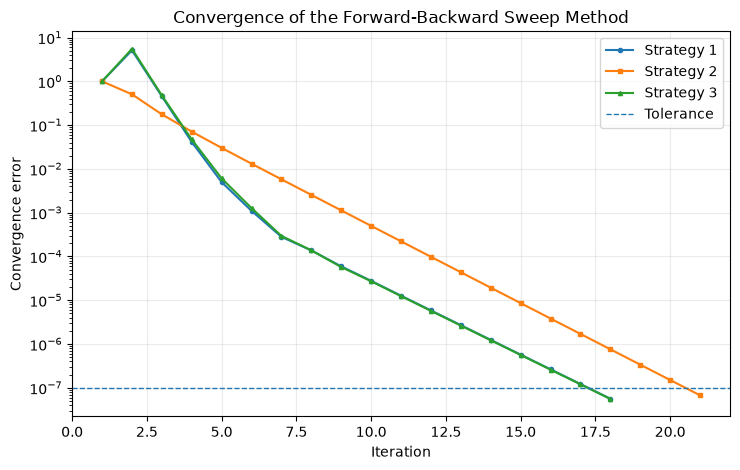

In [17]:
# ============================================================
# CONVERGENCE HISTORY
# ============================================================

plt.figure(figsize=(7.5, 4.8))


# ============================================================
# CONVERGENCE CURVES
# ============================================================

plt.semilogy(
    np.arange(1, len(result_s1["history"]) + 1),
    result_s1["history"],
    marker="o",
    markersize=3,
    label="Strategy 1"
)

plt.semilogy(
    np.arange(1, len(result_s2["history"]) + 1),
    result_s2["history"],
    marker="s",
    markersize=3,
    label="Strategy 2"
)

plt.semilogy(
    np.arange(1, len(result_s3["history"]) + 1),
    result_s3["history"],
    marker="^",
    markersize=3,
    label="Strategy 3"
)


# ============================================================
# CONVERGENCE TOLERANCE
# ============================================================

plt.axhline(y=tol, linestyle="--", linewidth=1, label="Tolerance")


# ============================================================
# PLOT SETTINGS
# ============================================================

plt.xlabel("Iteration")
plt.ylabel("Convergence error")
plt.title("Convergence of the Forward-Backward Sweep Method")

plt.legend()

plt.grid(True, alpha=0.25)

plt.tight_layout()

plt.show()

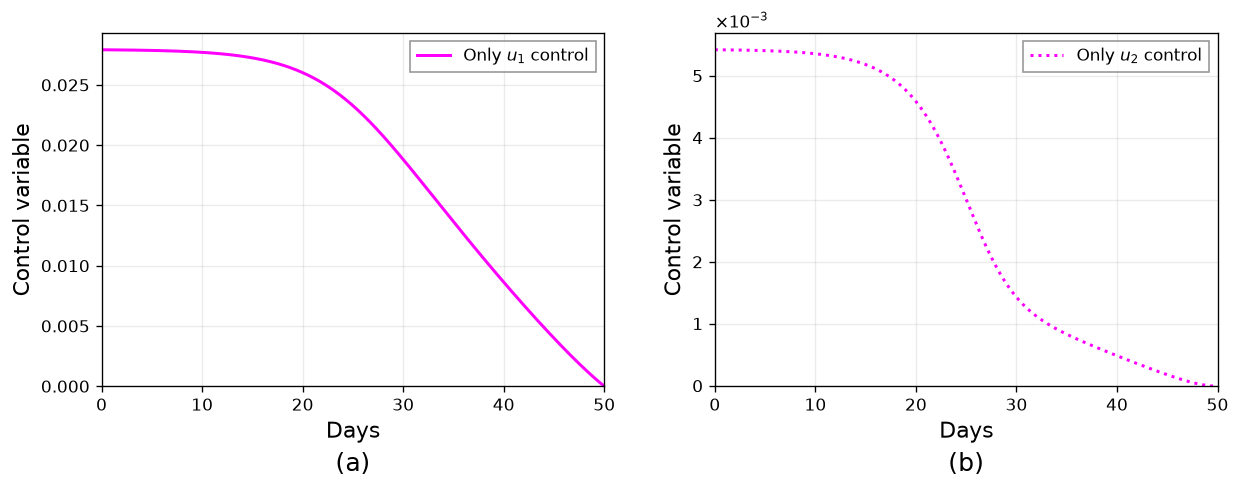

In [18]:
# ============================================================
# FIGURE 8
# OPTIMAL CONTROL VARIABLES
# ============================================================

fig, ax = plt.subplots(1, 2, figsize=(12, 4.6), dpi=120)


# ============================================================
# (a) u1 CONTROL
# ============================================================
ax[0].plot(t, result_s1["u1"], color="magenta", linewidth=1.8, label=r"Only $u_1$ control")
ax[0].set_xlim(0, 50)
ax[0].set_ylim(bottom=0)
ax[0].set_xlabel("Days", fontsize=13)
ax[0].set_ylabel("Control variable", fontsize=13)
ax[0].grid(True, alpha=0.25)
ax[0].legend(
    loc="upper right",
    fontsize=10,
    frameon=True,
    fancybox=False,
    edgecolor="gray"
)


# ============================================================
# (b) u2 CONTROL
# ============================================================

ax[1].plot(t, result_s2["u2"], color="magenta", linestyle=":", linewidth=1.8, label=r"Only $u_2$ control")
ax[1].set_xlim(0, 50)
ax[1].set_ylim(bottom=0)
ax[1].set_xlabel("Days", fontsize=13)
ax[1].set_ylabel("Control variable", fontsize=13)
ax[1].ticklabel_format(axis="y", style="sci", scilimits=(-3, -3), useMathText=True)
ax[1].grid(True, alpha=0.25)
ax[1].legend(
    loc="upper right",
    fontsize=10,
    frameon=True,
    fancybox=False,
    edgecolor="gray"
)


# ============================================================
# PANEL LABELS
# ============================================================

ax[0].text(0.5, -0.24, "(a)", transform=ax[0].transAxes, ha="center", fontsize=15)
ax[1].text(0.5, -0.24, "(b)", transform=ax[1].transAxes, ha="center", fontsize=15)


plt.subplots_adjust(bottom=0.24, wspace=0.22)

plt.show()

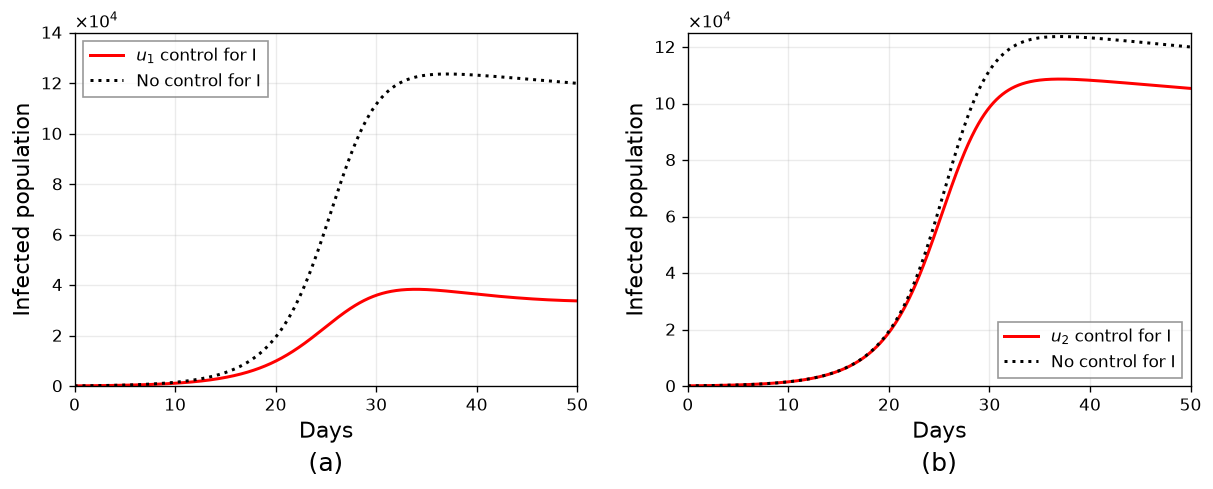

In [19]:
# ============================================================
# FIGURE 9
# INFECTED POPULATION
# ============================================================

fig, ax = plt.subplots(1, 2, figsize=(12, 4.6), dpi=120)


# ============================================================
# (a) u1 CONTROL
# ============================================================

ax[0].plot(t, result_s1["I"], color="red", linewidth=1.8, label=r"$u_1$ control for I")
ax[0].plot(t, I_no, color="black", linestyle=":", linewidth=1.8, label="No control for I")
ax[0].set_xlim(0, 50)
ax[0].set_ylim(0, 1.4e5)
ax[0].set_xlabel("Days", fontsize=13)
ax[0].set_ylabel("Infected population", fontsize=13)
ax[0].ticklabel_format(axis="y", style="sci", scilimits=(4, 4), useMathText=True)
ax[0].grid(True, alpha=0.25)
ax[0].legend(
    loc="upper left",
    fontsize=10,
    frameon=True,
    fancybox=False,
    edgecolor="gray"
)


# ============================================================
# (b) u2 CONTROL
# ============================================================

ax[1].plot(t, result_s2["I"], color="red", linewidth=1.8, label=r"$u_2$ control for I")
ax[1].plot(t, I_no, color="black", linestyle=":", linewidth=1.8, label="No control for I")
ax[1].set_xlim(0, 50)
ax[1].set_ylim(0, 1.25e5)
ax[1].set_xlabel("Days", fontsize=13)
ax[1].set_ylabel("Infected population", fontsize=13)
ax[1].ticklabel_format(axis="y", style="sci", scilimits=(4, 4), useMathText=True)
ax[1].grid(True, alpha=0.25)
ax[1].legend(
    loc="lower right",
    fontsize=10,
    frameon=True,
    fancybox=False,
    edgecolor="gray"
)


# ============================================================
# PANEL LABELS
# ============================================================

ax[0].text(0.5, -0.24, "(a)", transform=ax[0].transAxes, ha="center", fontsize=15)
ax[1].text(0.5, -0.24, "(b)", transform=ax[1].transAxes, ha="center", fontsize=15)


plt.subplots_adjust(bottom=0.24, wspace=0.22)

plt.show()

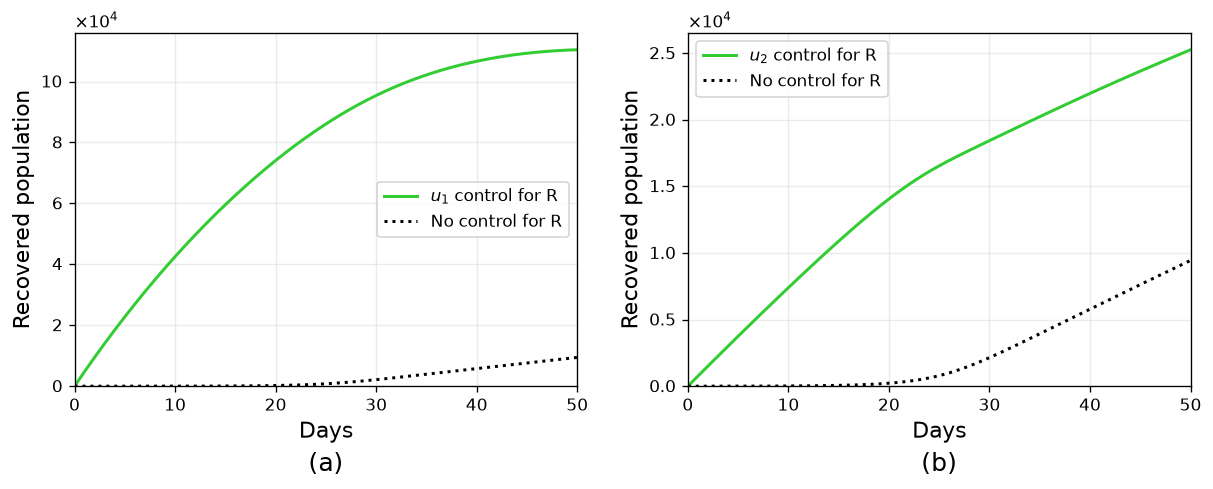

In [20]:
# ============================================================
# FIGURE 10
# RECOVERED POPULATION
# ============================================================

fig, ax = plt.subplots(1, 2, figsize=(12, 4.6), dpi=120)


# ============================================================
# (a) u1 CONTROL
# ============================================================

ax[0].plot(t, result_s1["R"], color="limegreen", linewidth=1.8, label=r"$u_1$ control for R")
ax[0].plot(t, R_no, color="black", linestyle=":", linewidth=1.8, label="No control for R")
ax[0].set_xlim(0, 50)
ax[0].set_ylim(bottom=0)
ax[0].set_xlabel("Days", fontsize=13)
ax[0].set_ylabel("Recovered population", fontsize=13)
ax[0].ticklabel_format(axis="y", style="sci", scilimits=(4, 4), useMathText=True)
ax[0].grid(True, alpha=0.25)
ax[0].legend(loc="center right", fontsize=10)


# ============================================================
# (b) u2 CONTROL
# ============================================================
ax[1].plot(t, result_s2["R"], color="limegreen", linewidth=1.8, label=r"$u_2$ control for R")
ax[1].plot(t, R_no, color="black", linestyle=":", linewidth=1.8, label="No control for R")
ax[1].set_xlim(0, 50)
ax[1].set_ylim(bottom=0)
ax[1].set_xlabel("Days", fontsize=13)
ax[1].set_ylabel("Recovered population", fontsize=13)
ax[1].ticklabel_format(axis="y", style="sci", scilimits=(4, 4), useMathText=True)
ax[1].grid(True, alpha=0.25)
ax[1].legend(loc="upper left", fontsize=10)


# ============================================================
# PANEL LABELS
# ============================================================

ax[0].text(0.5, -0.24, "(a)", transform=ax[0].transAxes, ha="center", fontsize=15)
ax[1].text(0.5, -0.24, "(b)", transform=ax[1].transAxes, ha="center", fontsize=15)


plt.subplots_adjust(bottom=0.24, wspace=0.22)

plt.show()

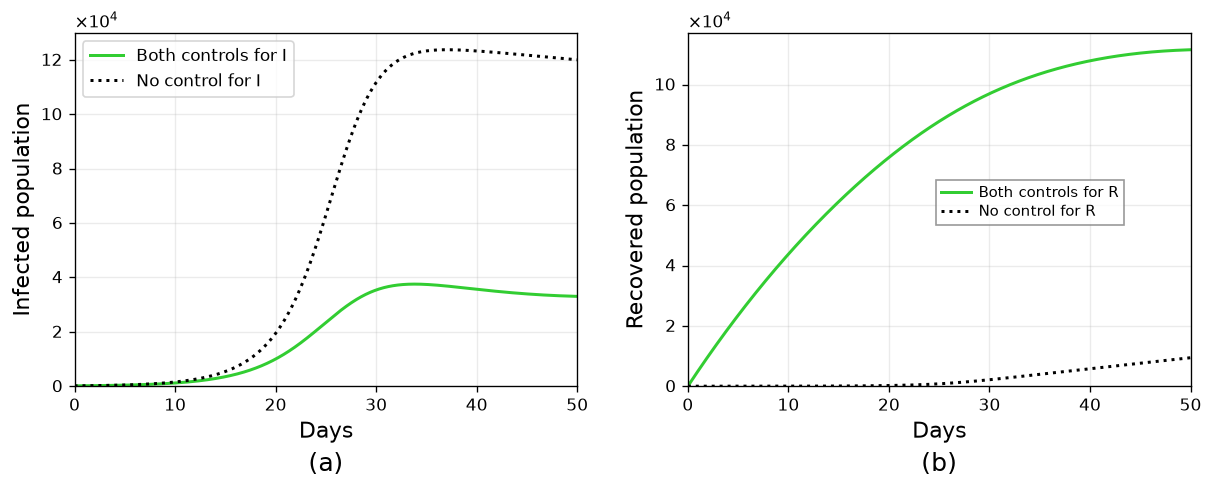

In [21]:
# ============================================================
# FIGURE 11
# BOTH CONTROLS VS NO CONTROL
# ============================================================

fig, ax = plt.subplots(1, 2, figsize=(12, 4.6), dpi=120)


# ============================================================
# (a) INFECTED POPULATION
# ============================================================

ax[0].plot(t, result_s3["I"], color="limegreen", linewidth=1.8, label="Both controls for I")
ax[0].plot(t, I_no, color="black", linestyle=":", linewidth=1.8, label="No control for I")
ax[0].set_xlim(0, 50)
ax[0].set_ylim(bottom=0)
ax[0].set_xlabel("Days", fontsize=13)
ax[0].set_ylabel("Infected population", fontsize=13)
ax[0].ticklabel_format(axis="y", style="sci", scilimits=(4, 4), useMathText=True)
ax[0].grid(True, alpha=0.25)
ax[0].legend(loc="upper left", fontsize=10)


# ============================================================
# (b) RECOVERED POPULATION
# ============================================================

ax[1].plot(t, result_s3["R"], color="limegreen", linewidth=1.8, label="Both controls for R")
ax[1].plot(t, R_no, color="black", linestyle=":", linewidth=1.8, label="No control for R")
ax[1].set_xlim(0, 50)
ax[1].set_ylim(bottom=0)
ax[1].set_xlabel("Days", fontsize=13)
ax[1].set_ylabel("Recovered population", fontsize=13)
ax[1].ticklabel_format(axis="y", style="sci", scilimits=(4, 4), useMathText=True)
ax[1].grid(True, alpha=0.25)
ax[1].legend(
    loc="center",
    bbox_to_anchor=(0.68, 0.52),
    fontsize=9,
    frameon=True,
    fancybox=False,
    edgecolor="gray",
    borderpad=0.35,
    labelspacing=0.25,
    handlelength=2.0,
    handletextpad=0.5
)


# ============================================================
# PANEL LABELS
# ============================================================

ax[0].text(0.5, -0.24, "(a)", transform=ax[0].transAxes, ha="center", fontsize=15)
ax[1].text(0.5, -0.24, "(b)", transform=ax[1].transAxes, ha="center", fontsize=15)


plt.subplots_adjust(bottom=0.24, wspace=0.22)

plt.show()

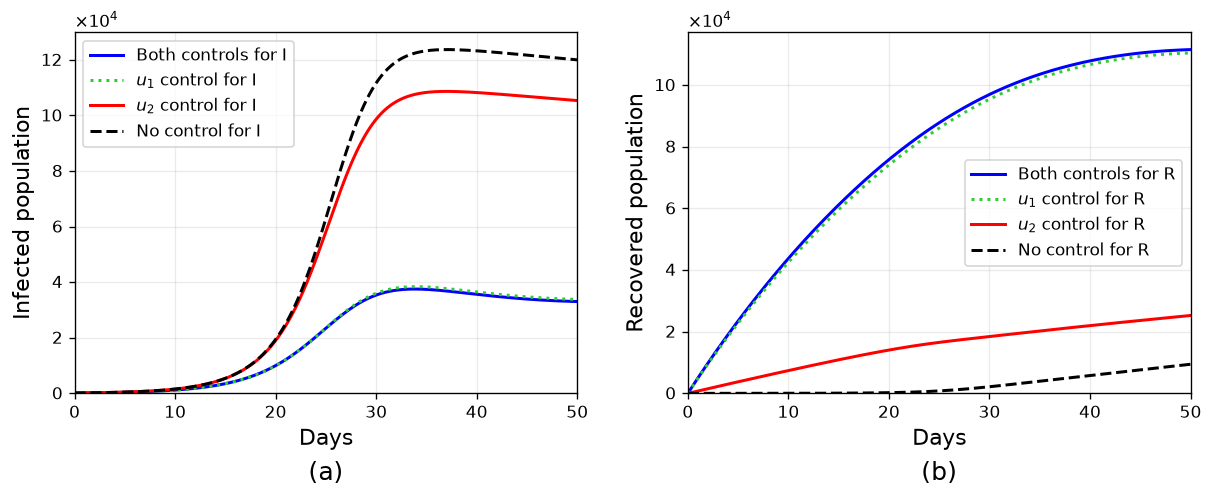

In [22]:
# ============================================================
# FIGURE 12
# COMPARISON OF ALL STRATEGIES
# ============================================================

fig, ax = plt.subplots(1, 2, figsize=(12, 4.7), dpi=120)


# ============================================================
# (a) INFECTED
# ============================================================
ax[0].plot(t, result_s3["I"], color="blue", linewidth=1.8, label="Both controls for I")
ax[0].plot(t, result_s1["I"], color="limegreen", linestyle=":", linewidth=1.8, label=r"$u_1$ control for I")
ax[0].plot(t, result_s2["I"], color="red", linewidth=1.8, label=r"$u_2$ control for I")
ax[0].plot(t, I_no, color="black", linestyle="--", linewidth=1.8, label="No control for I")
ax[0].set_xlim(0, 50)
ax[0].set_ylim(bottom=0)
ax[0].set_xlabel("Days", fontsize=13)
ax[0].set_ylabel("Infected population", fontsize=13)
ax[0].ticklabel_format(axis="y", style="sci", scilimits=(4, 4), useMathText=True)
ax[0].grid(True, alpha=0.25)
ax[0].legend(loc="upper left", fontsize=10)


# ============================================================
# (b) RECOVERED
# ============================================================
ax[1].plot( t, result_s3["R"], color="blue", linewidth=1.8, label="Both controls for R")
ax[1].plot(t, result_s1["R"], color="limegreen", linestyle=":", linewidth=1.8, label=r"$u_1$ control for R")
ax[1].plot(t, result_s2["R"], color="red", linewidth=1.8, label=r"$u_2$ control for R")
ax[1].plot(t, R_no, color="black", linestyle="--", linewidth=1.8, label="No control for R")
ax[1].set_xlim(0, 50)
ax[1].set_ylim(bottom=0)
ax[1].set_xlabel("Days",fontsize=13)
ax[1].set_ylabel("Recovered population", fontsize=13)
ax[1].ticklabel_format(axis="y", style="sci", scilimits=(4, 4), useMathText=True)
ax[1].grid(True,alpha=0.25)
ax[1].legend(loc="center right",fontsize=10)


ax[0].text(0.5, -0.24, "(a)", transform=ax[0].transAxes, ha="center", fontsize=15)
ax[1].text(0.5, -0.24, "(b)", transform=ax[1].transAxes, ha="center", fontsize=15)


plt.subplots_adjust(bottom=0.24, wspace=0.22)
plt.show()

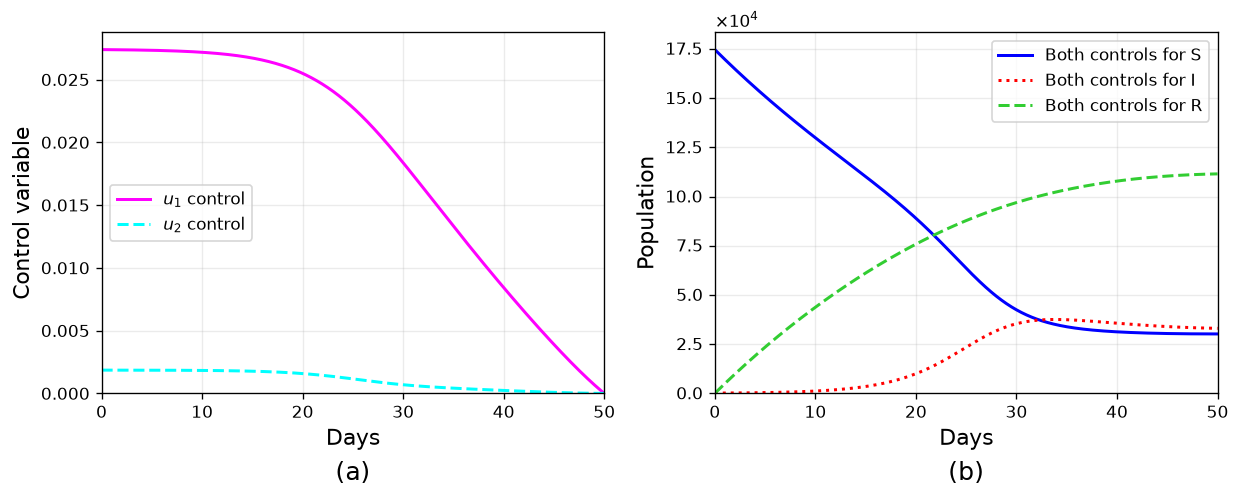

In [23]:
# ============================================================
# FIGURE 13
# BOTH CONTROLS AND SIR POPULATIONS
# ============================================================

fig, ax = plt.subplots(1,2,figsize=(12, 4.7),dpi=120)
# ============================================================
# (a) BOTH OPTIMAL CONTROLS
# ============================================================

ax[0].plot(t, result_s3["u1"], color="magenta", linewidth=1.8,label=r"$u_1$ control")
ax[0].plot(t, result_s3["u2"], color="cyan", linestyle="--", linewidth=1.8, label=r"$u_2$ control")
ax[0].set_xlim(0, 50)
ax[0].set_ylim(bottom=0)
ax[0].set_xlabel("Days",fontsize=13)
ax[0].set_ylabel("Control variable",fontsize=13)
ax[0].grid(True,alpha=0.25)
ax[0].legend(loc="center left",fontsize=10)


# ============================================================
# (b) SIR MODEL WITH BOTH CONTROLS
# ============================================================

ax[1].plot(t,result_s3["S"],color="blue",linewidth=1.8,label="Both controls for S")
ax[1].plot(t,result_s3["I"],color="red",linestyle=":",linewidth=1.8,label="Both controls for I")
ax[1].plot(t,result_s3["R"],color="limegreen",linestyle="--",linewidth=1.8,label="Both controls for R")
ax[1].set_xlim(0, 50)
ax[1].set_ylim(bottom=0)
ax[1].set_xlabel("Days",fontsize=13)
ax[1].set_ylabel("Population",fontsize=13)
ax[1].ticklabel_format(axis="y",style="sci",scilimits=(4, 4),useMathText=True)
ax[1].grid(True,alpha=0.25)
ax[1].legend(loc="upper right",fontsize=10)
ax[0].text(0.5, -0.24, "(a)",transform=ax[0].transAxes,ha="center",fontsize=15)
ax[1].text(0.5, -0.24, "(b)", transform=ax[1].transAxes,ha="center",fontsize=15)
plt.subplots_adjust(bottom=0.24,wspace=0.22)
plt.show()